In [1]:
from matplotlib import pyplot as plt
import numpy as np
from PIL import Image
from osgeo import gdal
import cv2
import torch
import torch.nn.functional as F

In [2]:
L1=dict(
    Vegetation=1,
    Water=2,
    Artificial_surface=3,
    Bare_land=4,
    )
# class_L2_{L1级标签中的标签值}_{L2级标签中的标签值}_{L2级标签中的标签名称}=[L3级标签中的值]
L2=dict(
    Crop_land=1,
    Forest=2,
    Grassland=3,
    Water=4,
    Factory_Shopping_malls=5,
    Residence=6,
    Public_area=7,
    Transportation_infrastructure=8,
    Bare_land=9,
    )
# class_L3_{L1级标签中的标签值}_{L2级标签中的标签值}_{L3级标签中的标签值}_{L3级标签中的标签名称}
L3=dict(
    Paddy_field=1,
    Dry_cropland=2,
    Forest=3,
    Natural_meadow=4,
    Artificial_meadow=5,
    River=6,
    Lake=7,
    Pond=8,
    Factory_shopping_malls=9,
    Urban_residential=10,
    Rural_residential=11,
    Stadium=12,
    Park_Square=13,
    Road=14,
    Overpass=15,
    Railway_station=16,
    Airport=17,
    Bare_land=18
    )


In [3]:
dir_path = '特征输出-2branch-loss_佳木斯市_桦南县_6_11'

L1_seglogits = np.load(f'./{dir_path}/L1_seglogits.npy')
L2_seglogits = np.load(f'./{dir_path}/L2_seglogits.npy')
L3_seglogits = np.load(f'./{dir_path}/L3_seglogits.npy')

L1_RGB = Image.open(f'./{dir_path}/L1_rgb_S2_2019_黑龙江省_佳木斯市_桦南县_6_11.tif')
L2_RGB = Image.open(f'./{dir_path}/L2_rgb_S2_2019_黑龙江省_佳木斯市_桦南县_6_11.tif')
L3_RGB = Image.open(f'./{dir_path}/L3_rgb_S2_2019_黑龙江省_佳木斯市_桦南县_6_11.tif')
crop_RGB = Image.open(f'./{dir_path}/crop_rgb_S2_2019_黑龙江省_佳木斯市_桦南县_6_11.tif')

img_path = f'./{dir_path}/S2_2019_黑龙江省_佳木斯市_桦南县_6_11.tif'



In [4]:
'Vegetation'  'Water'  'Artificial_surface'  'Bare_land'

'Crop_land' 'Forest' 'Grassland' 'Water' 'Factory_Shopping_malls' 'Residence' 'Public_area' 
'Transportation_infrastructure' 'Bare_land'

'Paddy_field'  'Dry_cropland' 'Forest' 'Natural_meadow' 'Artificial_meadow' 'River' 'Lake' 'Pond' 'Factory_shopping_malls'
'Urban_residential' 'Rural_residential' 'Stadium' 'Park_Square' 'Road' 'Overpass' 'Railway_station' 'Airport' 'Bare_land'

'Urban_residentialRural_residentialStadiumPark_SquareRoadOverpassRailway_stationAirportBare_land'

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.36155000000000004..4.10095].


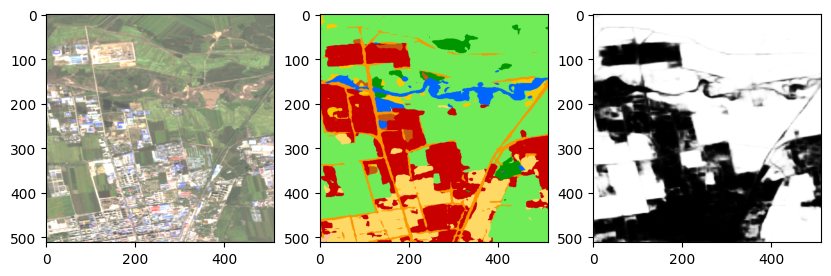

In [5]:
L_seglogits = L1_seglogits
name = L1['Vegetation']

img_ds = gdal.Open(img_path)
img_np = img_ds.ReadAsArray()
img_np = np.transpose(img_np, (1, 2, 0))/10000.0
img_vis = np.zeros((img_np.shape[0], img_np.shape[1], 3))
img_vis[:,:,0] = img_np[:,:,2]
img_vis[:,:,1] = img_np[:,:,1]
img_vis[:,:,2] = img_np[:,:,0] 
img_vis = img_vis * 3.5


# # softmax去处理多通道
# L1_vis = F.softmax(torch.from_numpy(L_seglogits), dim=1).numpy()
# L1_vis = L1_vis[0, name-1, :, :]


# sigmoid 处理单通道
L1_vis = L1_seglogits[0, name-1, :, :]
L1_vis = F.sigmoid(torch.from_numpy(L1_vis)).numpy()

# # 二值化阈值去处理
# L1_vis = L1_seglogits[0, name-1, :, :]
# L1_vis = cv2.threshold(L1_vis, 8, 1, cv2.THRESH_BINARY)[1]


plt.figure(figsize=(10, 5))  # 宽15，高5，可根据需要调整
plt.subplot(1, 3, 1)
plt.imshow(img_vis)
plt.subplot(1, 3, 2)
plt.imshow(L2_RGB)
plt.subplot(1, 3, 3)
plt.imshow(L1_vis, cmap='gray')
plt.show()

将softmax后的结果，保存成一张图，来查看其中的值

In [6]:
from ATL_Tools.ATL_gdal import save_array_to_tif
save_path = '/data/AI-Tianlong/openmmlab/mmsegmentation/configs_new/ATL-paper-new-hiera-3/7-part-3-跨领域-crop10m-Hiera/特征输出-2branch-loss_佳木斯市_桦南县_6_11/L1_植被sigmoid后的值.tif'

save_array_to_tif(img_array = L1_vis,
                  out_path = save_path,
                  Transform = img_ds.GetGeoTransform(),
                  Projection = img_ds.GetProjection(),
                  Band=1,
                  Datatype=gdal.GDT_Float32,
                  )


In [24]:
dir_path = '特征输出-2branch-loss_佳木斯市_桦南县_6_11'

L1_vegetation_seglogits_softmax = np.load(f'./{dir_path}/L1_vegetation_seglogits_softmax.npy').transpose(1, 2, 0)
L2_crop_seglogits_softmax = np.load(f'./{dir_path}/L2_crop_seglogits_softmax.npy').transpose(1, 2, 0)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.36155000000000004..4.10095].


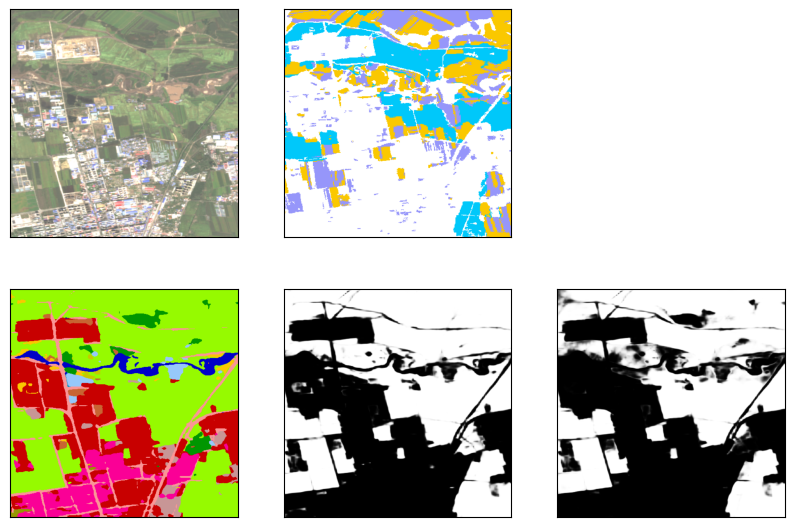

In [25]:

plt.figure(figsize=(10, 6.666))  # 宽15，高5，可根据需要调整
# 去掉坐标轴的数字，只显示坐标轴


plt.subplot(2, 3, 1)
plt.imshow(img_vis)
plt.xticks([])
plt.yticks([])


plt.subplot(2, 3, 2)
plt.imshow(crop_RGB)
plt.xticks([])
plt.yticks([])

plt.subplot(2, 3, 4)
plt.imshow(L3_RGB)
plt.xticks([])
plt.yticks([])

plt.subplot(2, 3, 5)
plt.imshow(L1_vegetation_seglogits_softmax, cmap='gray')
plt.xticks([])
plt.yticks([])

plt.subplot(2, 3, 6)
plt.imshow(L2_crop_seglogits_softmax, cmap='gray')
plt.xticks([])
plt.yticks([])

plt.show()

In [9]:
L1_seglogits.shape

(1, 4, 512, 512)